Loaded 3275 total user-delta records.


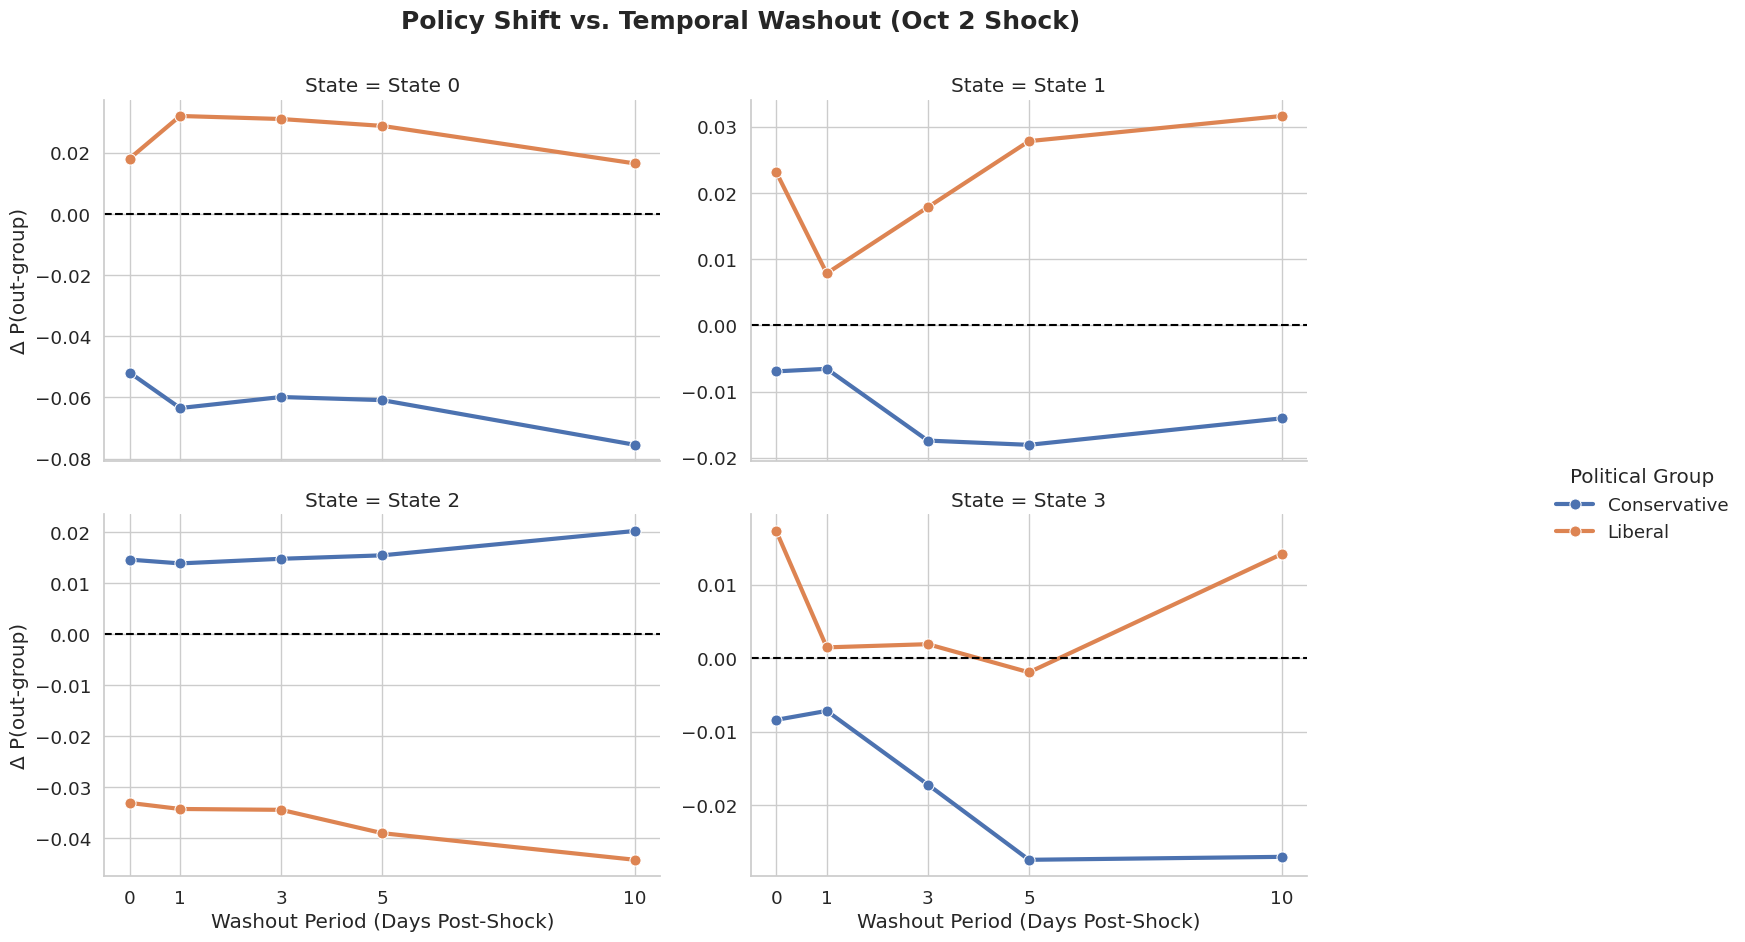

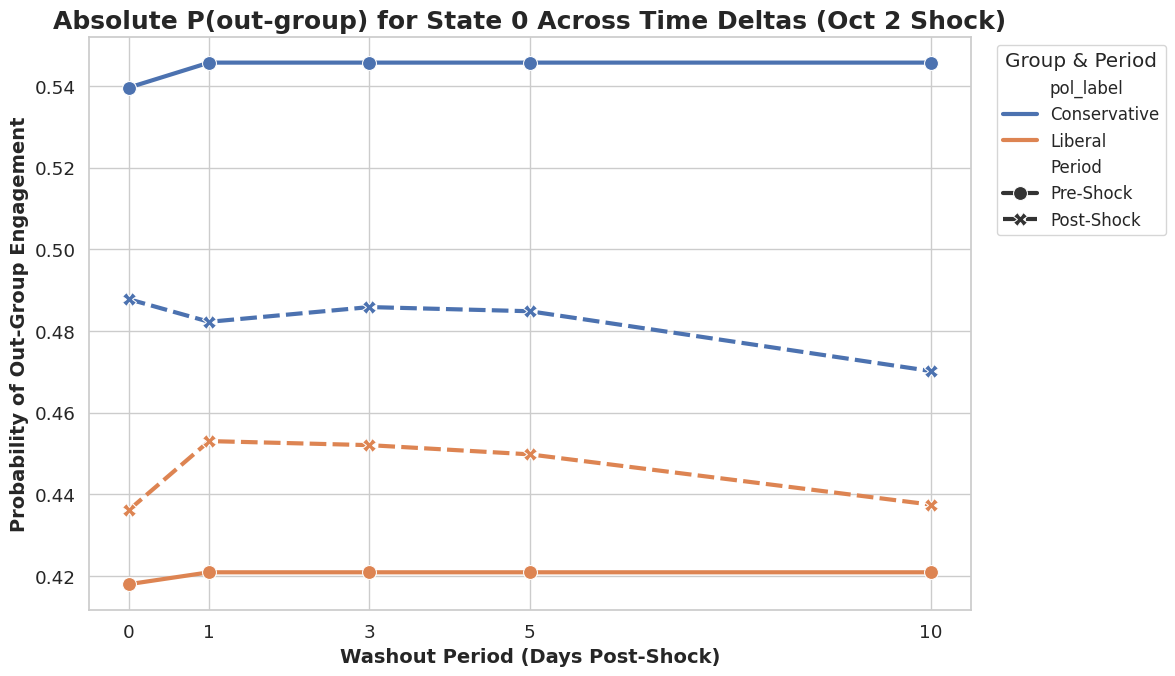

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. Setup and Data Loading
# ==============================================================================
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)

# UPDATED: Time-based lag in days
deltas = [0, 1, 3, 5, 10]
data_dir = "/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/time_delta_oct2_locked"
n_states = 4

df_list = []
for d in deltas:
    # UPDATED: File name format from your new execution script
    file_path = os.path.join(data_dir, f"time_delta_oct2_lag_{d}days.parquet")
    
    if os.path.exists(file_path):
        tmp_df = pd.read_parquet(file_path)
        tmp_df['delta_lag'] = d
        df_list.append(tmp_df)
    else:
        print(f"Warning: File not found for delta {d} days at: {file_path}")

df_all = pd.concat(df_list, ignore_index=True)
df_all['pol_label'] = df_all['pol'].map({0: 'Liberal', 1: 'Conservative'})

print(f"Loaded {len(df_all)} total user-delta records.")

# ==============================================================================
# 2. Calculate Mean Policies and Shifts
# ==============================================================================
policy_cols = [f"pre_policy_out_s{s}" for s in range(n_states)] + \
              [f"post_policy_out_s{s}" for s in range(n_states)]

agg_df = df_all.groupby(['delta_lag', 'pol_label'])[policy_cols].mean().reset_index()

for s in range(n_states):
    agg_df[f'shift_s{s}'] = agg_df[f'post_policy_out_s{s}'] - agg_df[f'pre_policy_out_s{s}']

# ==============================================================================
# 3. Visualizing the Effect of Lag on Policy Shift
# ==============================================================================
plot_df = pd.melt(
    agg_df, 
    id_vars=['delta_lag', 'pol_label'], 
    value_vars=[f'shift_s{s}' for s in range(n_states)],
    var_name='State', 
    value_name='Policy Shift (Post - Pre)'
)

plot_df['State'] = plot_df['State'].str.replace('shift_s', 'State ')

g = sns.FacetGrid(plot_df, col="State", col_wrap=2, height=4.5, aspect=1.5, sharey=False)
g.map_dataframe(sns.lineplot, x="delta_lag", y="Policy Shift (Post - Pre)", hue="pol_label", marker="o", linewidth=3, markersize=8)

g.refline(y=0, color='black', linestyle='--', linewidth=1.5)

# UPDATED: Axis labels and ticks to reflect days
g.set_axis_labels("Washout Period (Days Post-Shock)", "Δ P(out-group)")
g.set(xticks=deltas) 
g.add_legend(title="Political Group", bbox_to_anchor=(1.02, 0.5), loc='center left')
g.fig.suptitle("Policy Shift vs. Temporal Washout (Oct 2 Shock)", y=1.05, fontsize=18, fontweight='bold')

plt.show()

# ==============================================================================
# 4. Deep Dive into Absolute Values for a Specific State
# ==============================================================================
target_state = 0 # Change this to view states 1, 2, or 3

raw_plot_df = pd.melt(
    agg_df,
    id_vars=['delta_lag', 'pol_label'],
    value_vars=[f'pre_policy_out_s{target_state}', f'post_policy_out_s{target_state}'],
    var_name='Period',
    value_name='P(out-group)'
)

raw_plot_df['Period'] = raw_plot_df['Period'].apply(lambda x: "Pre-Shock" if "pre" in x else "Post-Shock")

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=raw_plot_df, 
    x='delta_lag', 
    y='P(out-group)', 
    hue='pol_label', 
    style='Period', 
    markers=True, 
    dashes=True,
    linewidth=3,
    markersize=10
)

plt.title(f"Absolute P(out-group) for State {target_state} Across Time Deltas (Oct 2 Shock)", fontsize=18, fontweight='bold')

# UPDATED: Axis labels and ticks to reflect days
plt.xlabel("Washout Period (Days Post-Shock)", fontsize=14, fontweight='bold')
plt.ylabel("Probability of Out-Group Engagement", fontsize=14, fontweight='bold')
plt.xticks(deltas)
plt.legend(title="Group & Period", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

In [4]:
from scipy.stats import wilcoxon
from IPython.display import display, HTML

# ==============================================================================
# Statistical Testing for Policy Shifts (5 Separate Tables by Delta)
# ==============================================================================

format_dict = {
    'Pre Mean': '{:.4f}',
    'Post Mean': '{:.4f}',
    'Shift (Δ)': '{:+.4f}',
    'p-value': '{:.4f}'
}

# Iterate through each Delta to create and display a separate table
for d in sorted(df_all['delta_lag'].unique()):
    stats_results = []
    
    for pol in ['Liberal', 'Conservative']:
        subset = df_all[(df_all['delta_lag'] == d) & (df_all['pol_label'] == pol)]
        
        if len(subset) == 0:
            continue
            
        for s in range(n_states):
            pre_vals = subset[f'pre_policy_out_s{s}'].values
            post_vals = subset[f'post_policy_out_s{s}'].values
            
            mean_pre = pre_vals.mean()
            mean_post = post_vals.mean()
            shift = mean_post - mean_pre
            
            try:
                stat, p_val = wilcoxon(pre_vals, post_vals)
            except ValueError:
                p_val = 1.0
                
            if p_val < 0.001:
                sig = "***"
            elif p_val < 0.01:
                sig = "**"
            elif p_val < 0.05:
                sig = "*"
            else:
                sig = "ns"
                
            stats_results.append({
                'Group': pol,
                'State': f"State {s}",
                'N Users': len(subset),
                'Pre Mean': mean_pre,
                'Post Mean': mean_post,
                'Shift (Δ)': shift,
                'p-value': p_val,
                'Sig': sig
            })
            
    if not stats_results:
        continue

    stats_df = pd.DataFrame(stats_results)
    
    styled_table = stats_df.style.format(format_dict).set_caption(
        f"Delta Lag = {d} Days"
    ).set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '16px'), ('font-weight', 'bold')]
    }])
    
    display(styled_table)
    display(HTML("<br>"))

,Group,State,N Users,Pre Mean,Post Mean,Shift (Δ),p-value,Sig
0,Liberal,State 0,536,0.4180,0.4362,+0.0182,0.1036,ns
1,Liberal,State 1,536,0.4138,0.4370,+0.0232,0.0204,*
2,Liberal,State 2,536,0.4698,0.4367,-0.0331,0.0002,***
3,Liberal,State 3,536,0.4195,0.4368,+0.0173,0.2212,ns
4,Conservative,State 0,119,0.5396,0.4878,-0.0518,0.0259,*
5,Conservative,State 1,119,0.5125,0.5056,-0.0069,0.9662,ns
6,Conservative,State 2,119,0.4782,0.4928,+0.0146,0.2769,ns
7,Conservative,State 3,119,0.5096,0.5012,-0.0084,0.6772,ns


,Group,State,N Users,Pre Mean,Post Mean,Shift (Δ),p-value,Sig
0,Liberal,State 0,536,0.4209,0.4530,+0.0321,0.0036,**
1,Liberal,State 1,536,0.4116,0.4195,+0.0079,0.2905,ns
2,Liberal,State 2,536,0.4703,0.4360,-0.0343,0.0002,***
3,Liberal,State 3,536,0.4216,0.4231,+0.0015,0.9900,ns
4,Conservative,State 0,119,0.5457,0.4822,-0.0635,0.0113,*
5,Conservative,State 1,119,0.5131,0.5065,-0.0066,0.9619,ns
6,Conservative,State 2,119,0.4766,0.4904,+0.0139,0.3035,ns
7,Conservative,State 3,119,0.5161,0.5089,-0.0072,0.7164,ns


,Group,State,N Users,Pre Mean,Post Mean,Shift (Δ),p-value,Sig
0,Liberal,State 0,536,0.4209,0.4520,+0.0311,0.0038,**
1,Liberal,State 1,536,0.4116,0.4295,+0.0179,0.1031,ns
2,Liberal,State 2,536,0.4703,0.4359,-0.0345,0.0001,***
3,Liberal,State 3,536,0.4216,0.4235,+0.0019,0.8142,ns
4,Conservative,State 0,119,0.5457,0.4858,-0.0599,0.0138,*
5,Conservative,State 1,119,0.5131,0.4957,-0.0174,0.5722,ns
6,Conservative,State 2,119,0.4766,0.4914,+0.0148,0.2040,ns
7,Conservative,State 3,119,0.5161,0.4989,-0.0172,0.3687,ns


,Group,State,N Users,Pre Mean,Post Mean,Shift (Δ),p-value,Sig
0,Liberal,State 0,536,0.4209,0.4498,+0.0289,0.0076,**
1,Liberal,State 1,536,0.4116,0.4395,+0.0279,0.0067,**
2,Liberal,State 2,536,0.4703,0.4313,-0.0390,0.0000,***
3,Liberal,State 3,536,0.4216,0.4197,-0.0019,0.8858,ns
4,Conservative,State 0,119,0.5457,0.4848,-0.0609,0.0092,**
5,Conservative,State 1,119,0.5131,0.4950,-0.0180,0.6849,ns
6,Conservative,State 2,119,0.4766,0.4920,+0.0155,0.1397,ns
7,Conservative,State 3,119,0.5161,0.4887,-0.0274,0.2575,ns


,Group,State,N Users,Pre Mean,Post Mean,Shift (Δ),p-value,Sig
0,Liberal,State 0,536,0.4209,0.4375,+0.0166,0.1277,ns
1,Liberal,State 1,536,0.4116,0.4433,+0.0317,0.0018,**
2,Liberal,State 2,536,0.4703,0.4261,-0.0443,0.0000,***
3,Liberal,State 3,536,0.4216,0.4358,+0.0142,0.2154,ns
4,Conservative,State 0,119,0.5457,0.4702,-0.0755,0.0004,***
5,Conservative,State 1,119,0.5131,0.4990,-0.0140,0.7223,ns
6,Conservative,State 2,119,0.4766,0.4968,+0.0202,0.0892,ns
7,Conservative,State 3,119,0.5161,0.4891,-0.0270,0.2852,ns


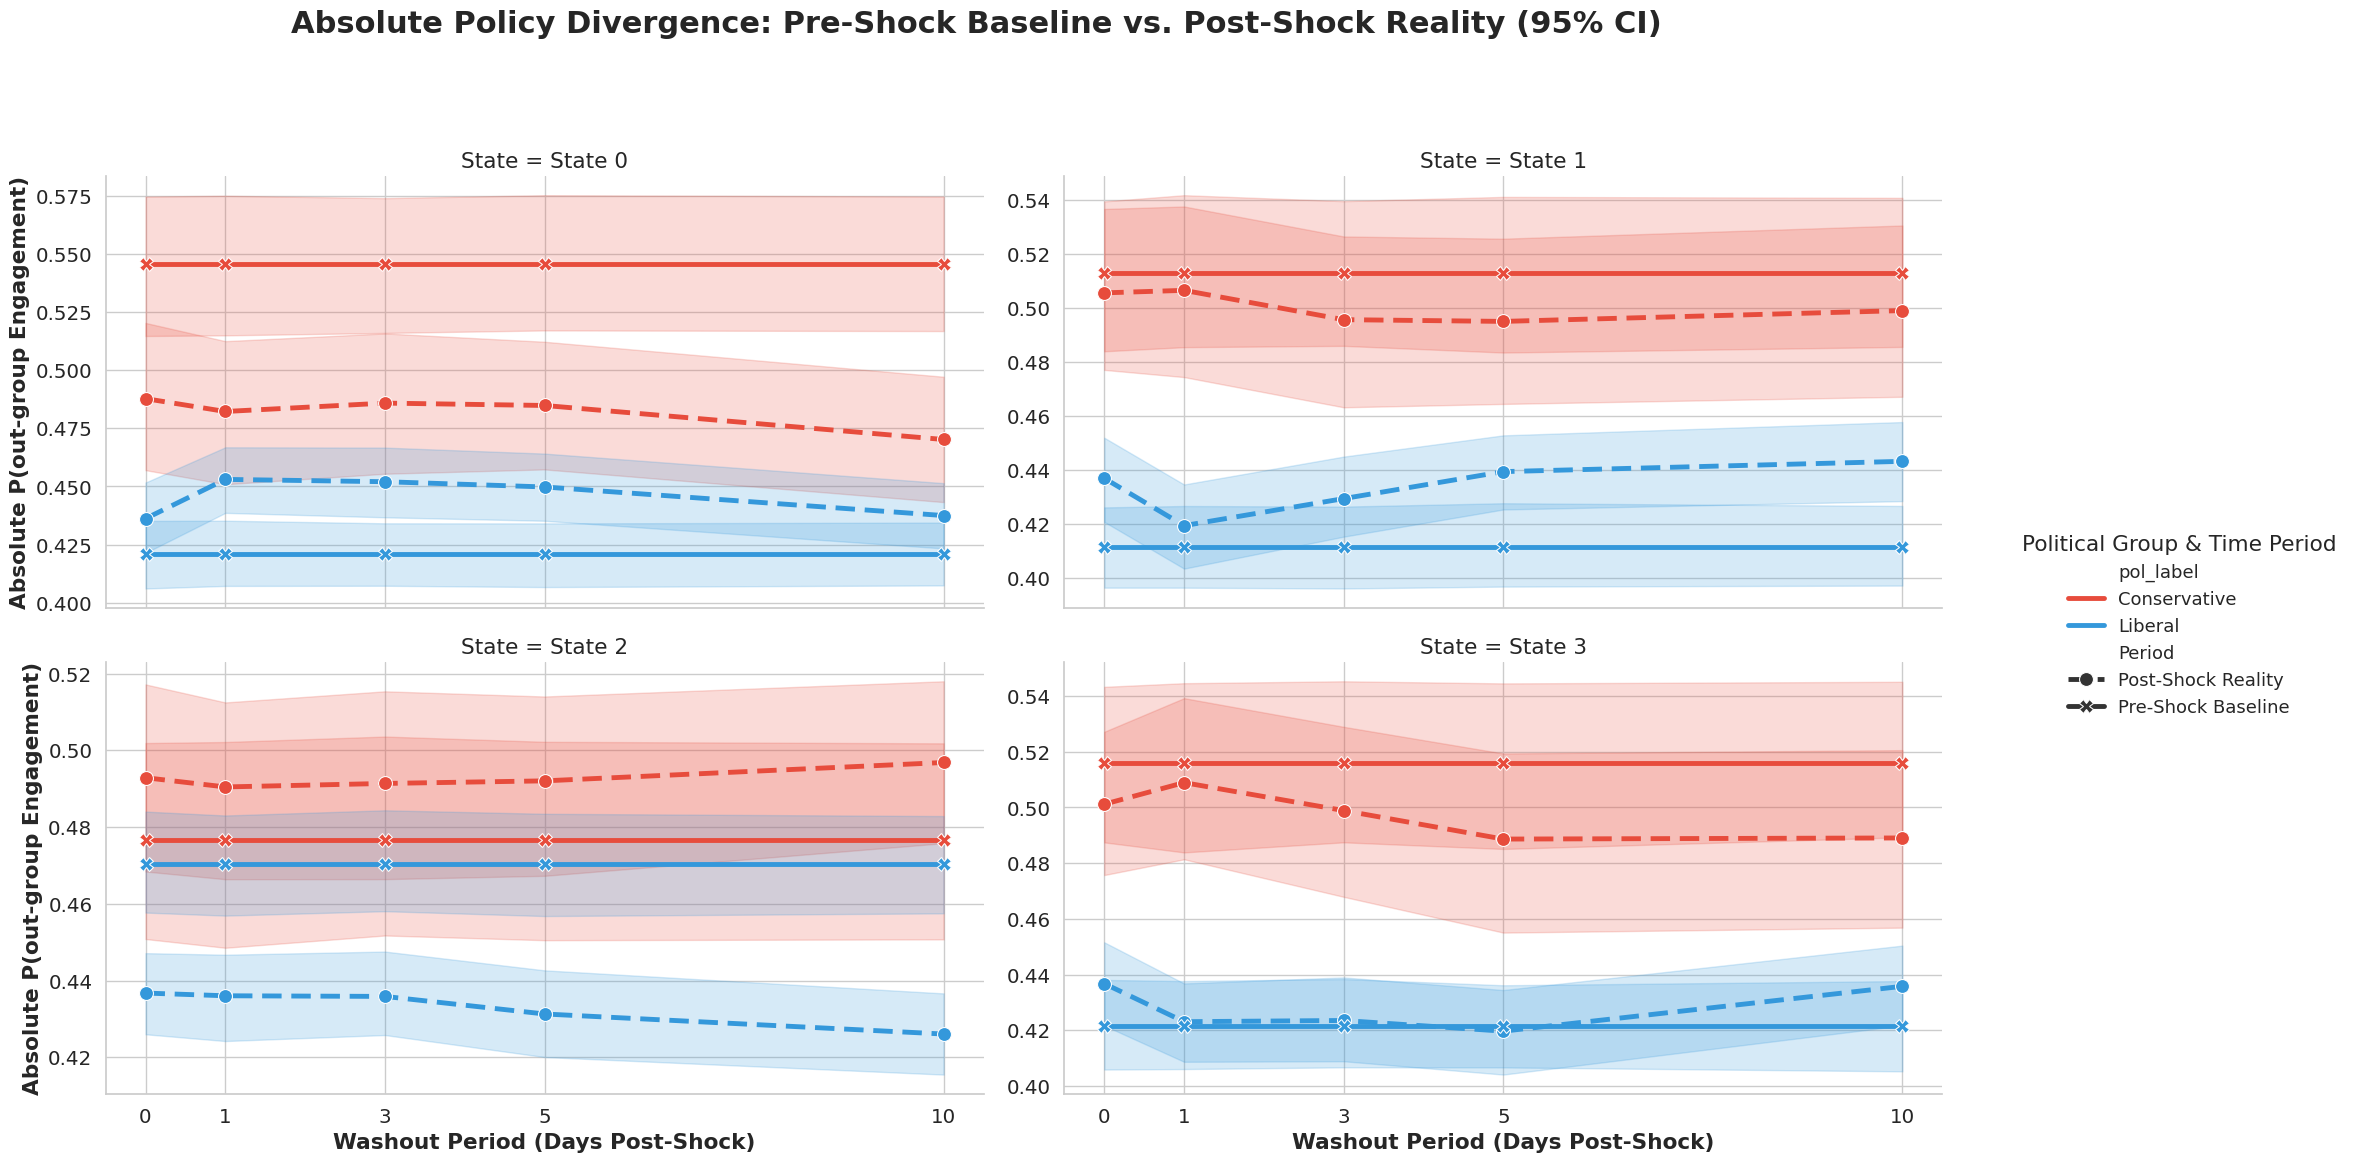

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. Setup and Data Loading
# ==============================================================================
sns.set_theme(style="whitegrid", font_scale=1.3)
plt.rcParams['figure.figsize'] = (16, 12)

deltas = [0, 1, 3, 5, 10]
data_dir = "/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/time_delta_oct2_locked"
n_states = 4

df_list = []
for d in deltas:
    file_path = os.path.join(data_dir, f"time_delta_oct2_lag_{d}days.parquet")
    if os.path.exists(file_path):
        tmp_df = pd.read_parquet(file_path)
        tmp_df['delta_lag'] = d
        df_list.append(tmp_df)
    else:
        print(f"Warning: File not found for delta {d} days")

df_all = pd.concat(df_list, ignore_index=True)
df_all['pol_label'] = df_all['pol'].map({0: 'Liberal', 1: 'Conservative'})

# ==============================================================================
# 2. Prepare Raw Data & APPLY THE DAY 0 FIX FOR CI BANDS
# ==============================================================================
policy_cols = [f"pre_policy_out_s{s}" for s in range(n_states)] + \
              [f"post_policy_out_s{s}" for s in range(n_states)]

# Melt the RAW dataframe so Seaborn has access to the variance to draw CI bands
plot_df_raw = pd.melt(
    df_all, 
    id_vars=['delta_lag', 'pol_label'], 
    value_vars=policy_cols,
    var_name='Metric', 
    value_name='P(out-group)'
)

plot_df_raw['Period'] = plot_df_raw['Metric'].apply(lambda x: 'Pre-Shock Baseline' if 'pre_' in x else 'Post-Shock Reality')
plot_df_raw['State'] = plot_df_raw['Metric'].apply(lambda x: 'State ' + x[-1])

# --- THE DAY 0 FIX (RAW DATA VERSION) ---
# Separate the post-shock reality (which naturally changes day-to-day)
post_reality = plot_df_raw[plot_df_raw['Period'] == 'Post-Shock Reality'].copy()

# Isolate ONLY the stable Day 10 Pre-Shock Baseline raw data
pre_day10 = plot_df_raw[(plot_df_raw['Period'] == 'Pre-Shock Baseline') & (plot_df_raw['delta_lag'] == 10)].copy()

# Replicate this stable baseline distribution for all time deltas
fixed_pre_baselines = []
for d in deltas:
    tmp = pre_day10.copy()
    tmp['delta_lag'] = d
    fixed_pre_baselines.append(tmp)

pre_baseline = pd.concat(fixed_pre_baselines, ignore_index=True)

# Recombine into the final plot dataframe
plot_df = pd.concat([post_reality, pre_baseline], ignore_index=True)

# ==============================================================================
# 3. Plotting the Absolute Pre vs Post Grid (With CI Bands)
# ==============================================================================
palette = {'Conservative': '#e74c3c', 'Liberal': '#3498db'}

g = sns.FacetGrid(plot_df, col="State", col_wrap=2, height=5.5, aspect=1.5, sharey=False)

# Pass the raw data and let Seaborn automatically bootstrap the 95% CI bands
g.map_dataframe(
    sns.lineplot, 
    x="delta_lag", 
    y="P(out-group)", 
    hue="pol_label", 
    style="Period", 
    palette=palette,
    markers=True, 
    dashes={'Pre-Shock Baseline': '', 'Post-Shock Reality': (4, 2)},
    linewidth=3.5, 
    markersize=10,
    err_style="band",         # Instructs Seaborn to draw the shaded band
    errorbar=('ci', 95)       # 95% Confidence Interval
)

g.set_axis_labels("Washout Period (Days Post-Shock)", "Absolute P(out-group Engagement)", fontweight='bold')
g.set(xticks=deltas) 

g.add_legend(title="Political Group & Time Period", bbox_to_anchor=(1.02, 0.5), loc='center left', fontsize=13, title_fontsize=15)
g.fig.suptitle("Absolute Policy Divergence: Pre-Shock Baseline vs. Post-Shock Reality (95% CI)", y=1.06, fontsize=22, fontweight='bold')

plt.tight_layout()
plt.show()

Loading data from: /nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/time_delta_oct2_locked/time_delta_oct2_lag_0days.parquet
Calculating Pre-Shock and Post-Shock metrics...
Generating visualization...
--> Saved high-res plot to: /nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/cluster_users/irl_pre_post_metrics_k2_to_k7.png
Pipeline complete!


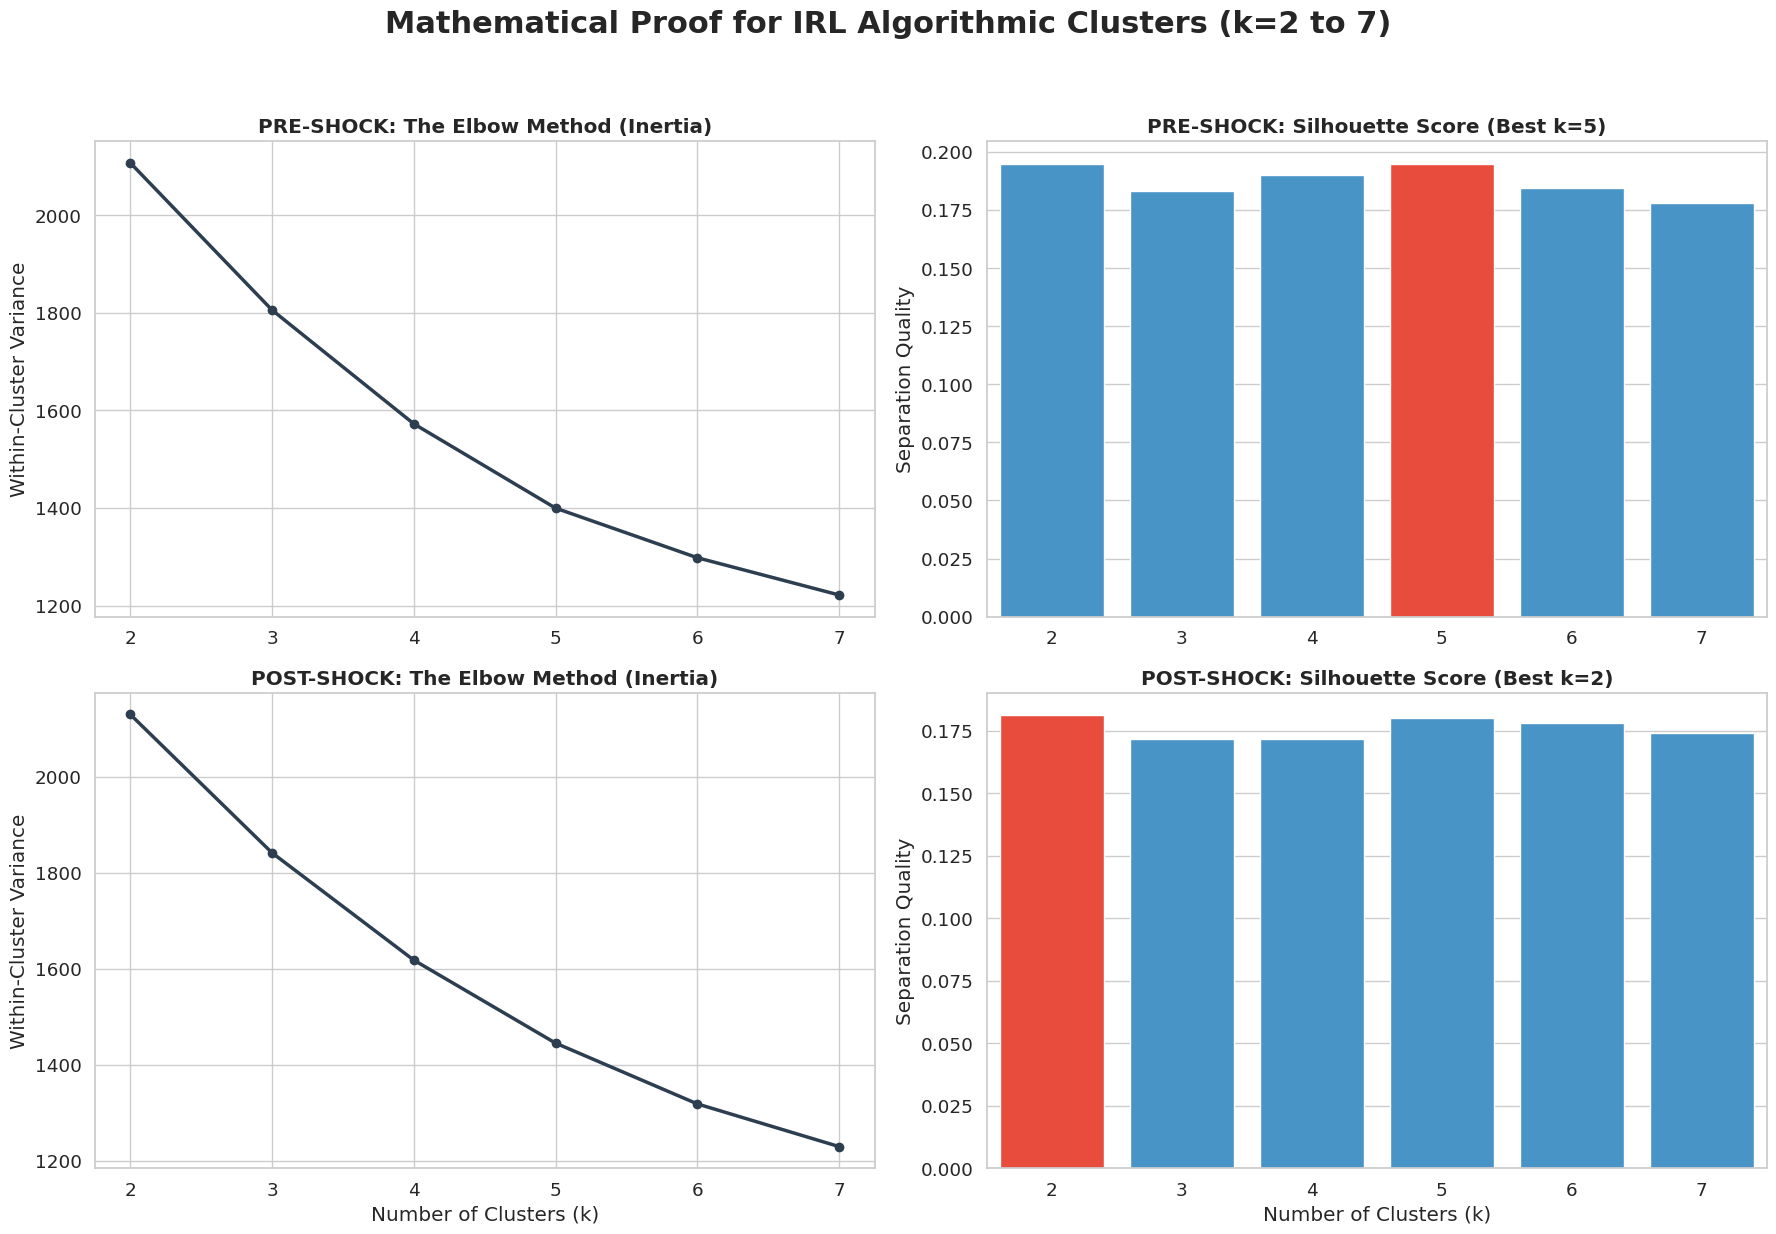

In [9]:
#!/usr/bin/env python3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# 1. Setup Directories & Load Data
# ==============================================================================
out_dir = "/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/cluster_users"
os.makedirs(out_dir, exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.2)

# Load the Day 0 locked cohort
input_file = "/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/time_delta_oct2_locked/time_delta_oct2_lag_0days.parquet"
print(f"Loading data from: {input_file}", flush=True)

df = pd.read_parquet(input_file)

# ==============================================================================
# 2. Extract Features
# ==============================================================================
pre_features = [f"pre_policy_out_s{s}" for s in range(4)]
post_features = [f"post_policy_out_s{s}" for s in range(4)]

X_pre = StandardScaler().fit_transform(df[pre_features].dropna())
X_post = StandardScaler().fit_transform(df[post_features].dropna())

# ==============================================================================
# 3. Calculate Metrics (k=2 through 7)
# ==============================================================================
print("Calculating Pre-Shock and Post-Shock metrics...", flush=True)
K_range = range(2, 8)

pre_inertia, pre_sil = [], []
post_inertia, post_sil = [], []

for k in K_range:
    # Pre-Shock
    kmeans_pre = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_pre)
    pre_inertia.append(kmeans_pre.inertia_)
    pre_sil.append(silhouette_score(X_pre, kmeans_pre.labels_))
    
    # Post-Shock
    kmeans_post = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_post)
    post_inertia.append(kmeans_post.inertia_)
    post_sil.append(silhouette_score(X_post, kmeans_post.labels_))

# ==============================================================================
# 4. Generate the 2x2 Plot
# ==============================================================================
print("Generating visualization...", flush=True)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ---- ROW 1: PRE-SHOCK METRICS ----
axes[0, 0].plot(K_range, pre_inertia, marker='o', linewidth=2.5, color='#2c3e50')
axes[0, 0].set_title("PRE-SHOCK: The Elbow Method (Inertia)", fontweight='bold')
axes[0, 0].set_ylabel("Within-Cluster Variance")

sns.barplot(x=list(K_range), y=pre_sil, color='#3498db', ax=axes[0, 1])
axes[0, 1].patches[np.argmax(pre_sil)].set_facecolor('#e74c3c') # Highlight best K
axes[0, 1].set_title(f"PRE-SHOCK: Silhouette Score (Best k={K_range[np.argmax(pre_sil)]})", fontweight='bold')
axes[0, 1].set_ylabel("Separation Quality")

# ---- ROW 2: POST-SHOCK METRICS ----
axes[1, 0].plot(K_range, post_inertia, marker='o', linewidth=2.5, color='#2c3e50')
axes[1, 0].set_title("POST-SHOCK: The Elbow Method (Inertia)", fontweight='bold')
axes[1, 0].set_xlabel("Number of Clusters (k)")
axes[1, 0].set_ylabel("Within-Cluster Variance")

sns.barplot(x=list(K_range), y=post_sil, color='#3498db', ax=axes[1, 1])
axes[1, 1].patches[np.argmax(post_sil)].set_facecolor('#e74c3c') # Highlight best K
axes[1, 1].set_title(f"POST-SHOCK: Silhouette Score (Best k={K_range[np.argmax(post_sil)]})", fontweight='bold')
axes[1, 1].set_xlabel("Number of Clusters (k)")
axes[1, 1].set_ylabel("Separation Quality")

plt.suptitle("Mathematical Proof for IRL Algorithmic Clusters (k=2 to 7)", y=1.03, fontsize=22, fontweight='bold')
plt.tight_layout()

# Save the plot
plot_out_path = os.path.join(out_dir, "irl_pre_post_metrics_k2_to_k7.png")
plt.savefig(plot_out_path, dpi=300, bbox_inches='tight')
print(f"--> Saved high-res plot to: {plot_out_path}", flush=True)
print("Pipeline complete!", flush=True)

Loading data from: /nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/time_delta_oct2_locked/time_delta_oct2_lag_0days.parquet
Clustering Pre-Shock Policy Space (Forcing k=2)...
Clustering Post-Shock Policy Space (Forcing k=2)...
Generating visualization...
--> Saved high-res plot to: /nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/cluster_users/irl_policy_pre_vs_post_k2.png
--> Saved clustered dataframe to: /nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/cluster_users/irl_policy_pre_vs_post_k2.parquet
Pipeline complete!


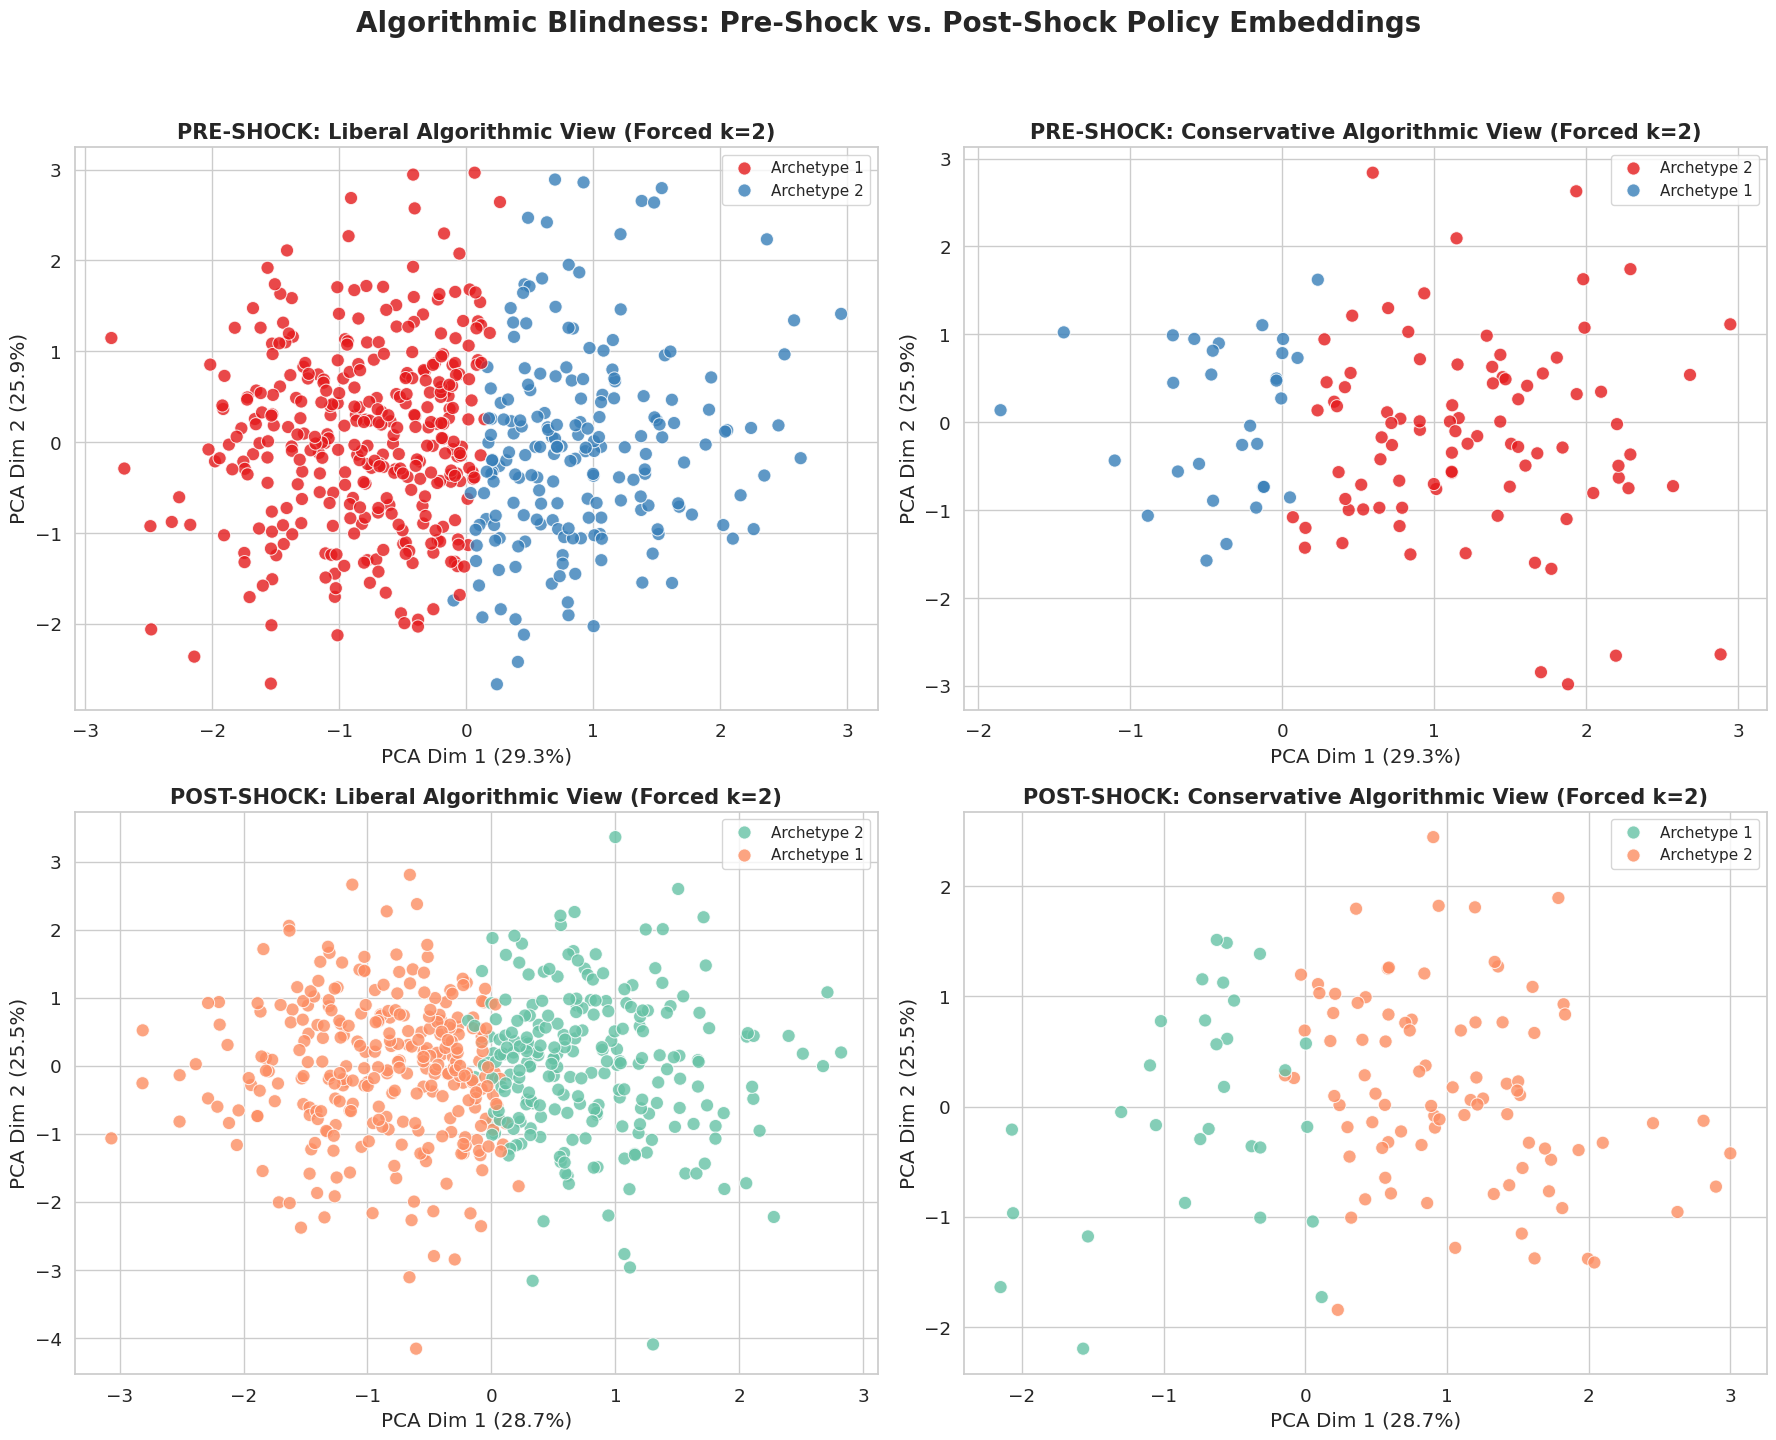

In [10]:
#!/usr/bin/env python3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==============================================================================
# 1. Setup Directories & Load Data
# ==============================================================================
out_dir = "/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/cluster_users"
os.makedirs(out_dir, exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.2)

# Load the Day 0 locked cohort
input_file = "/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/time_delta_oct2_locked/time_delta_oct2_lag_0days.parquet"
print(f"Loading data from: {input_file}", flush=True)

df = pd.read_parquet(input_file)
df['pol_label'] = df['pol'].map({0: 'Liberal', 1: 'Conservative'})

# ==============================================================================
# 2. Pipeline Definition (Forced k=2 + PCA)
# ==============================================================================
def get_clusters_and_pca_fixed_k(df, feature_cols, k=2):
    """Scales, clusters with a fixed k, and runs PCA for 2D visualization."""
    X = df[feature_cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Final Fit with Fixed K
    final_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = final_kmeans.fit_predict(X_scaled)
    
    # PCA for 2D visualization
    pca = PCA(n_components=2)
    pca_coords = pca.fit_transform(X_scaled)
    var_ratio = pca.explained_variance_ratio_ * 100
    
    return labels, pca_coords, var_ratio

# ==============================================================================
# 3. Process Pre-Shock and Post-Shock Separately (k=2)
# ==============================================================================
fixed_k = 2

print(f"Clustering Pre-Shock Policy Space (Forcing k={fixed_k})...", flush=True)
pre_features = [f"pre_policy_out_s{s}" for s in range(4)]
pre_labels, pre_pca, pre_var = get_clusters_and_pca_fixed_k(df, pre_features, k=fixed_k)
df['Pre_Cluster'] = [f"Archetype {x+1}" for x in pre_labels]
df['Pre_PCA_1'] = pre_pca[:, 0]
df['Pre_PCA_2'] = pre_pca[:, 1]

print(f"Clustering Post-Shock Policy Space (Forcing k={fixed_k})...", flush=True)
post_features = [f"post_policy_out_s{s}" for s in range(4)]
post_labels, post_pca, post_var = get_clusters_and_pca_fixed_k(df, post_features, k=fixed_k)
df['Post_Cluster'] = [f"Archetype {x+1}" for x in post_labels]
df['Post_PCA_1'] = post_pca[:, 0]
df['Post_PCA_2'] = post_pca[:, 1]

# ==============================================================================
# 4. Generate the 2x2 Visualization Grid
# ==============================================================================
print("Generating visualization...", flush=True)
fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharex=False, sharey=False)

palette_pre = sns.color_palette("Set1", fixed_k)
palette_post = sns.color_palette("Set2", fixed_k)

# ---- ROW 1: PRE-SHOCK (Left: Liberal, Right: Conservative) ----
sns.scatterplot(
    data=df[df['pol_label'] == 'Liberal'], x='Pre_PCA_1', y='Pre_PCA_2', 
    hue='Pre_Cluster', palette=palette_pre, s=90, alpha=0.8, edgecolor='w', ax=axes[0, 0]
)
axes[0, 0].set_title(f"PRE-SHOCK: Liberal Algorithmic View (Forced k={fixed_k})", fontsize=15, fontweight='bold')
axes[0, 0].set_xlabel(f"PCA Dim 1 ({pre_var[0]:.1f}%)")
axes[0, 0].set_ylabel(f"PCA Dim 2 ({pre_var[1]:.1f}%)")

sns.scatterplot(
    data=df[df['pol_label'] == 'Conservative'], x='Pre_PCA_1', y='Pre_PCA_2', 
    hue='Pre_Cluster', palette=palette_pre, s=90, alpha=0.8, edgecolor='w', ax=axes[0, 1]
)
axes[0, 1].set_title(f"PRE-SHOCK: Conservative Algorithmic View (Forced k={fixed_k})", fontsize=15, fontweight='bold')
axes[0, 1].set_xlabel(f"PCA Dim 1 ({pre_var[0]:.1f}%)")
axes[0, 1].set_ylabel(f"PCA Dim 2 ({pre_var[1]:.1f}%)")

# ---- ROW 2: POST-SHOCK (Left: Liberal, Right: Conservative) ----
sns.scatterplot(
    data=df[df['pol_label'] == 'Liberal'], x='Post_PCA_1', y='Post_PCA_2', 
    hue='Post_Cluster', palette=palette_post, s=90, alpha=0.8, edgecolor='w', ax=axes[1, 0]
)
axes[1, 0].set_title(f"POST-SHOCK: Liberal Algorithmic View (Forced k={fixed_k})", fontsize=15, fontweight='bold')
axes[1, 0].set_xlabel(f"PCA Dim 1 ({post_var[0]:.1f}%)")
axes[1, 0].set_ylabel(f"PCA Dim 2 ({post_var[1]:.1f}%)")

sns.scatterplot(
    data=df[df['pol_label'] == 'Conservative'], x='Post_PCA_1', y='Post_PCA_2', 
    hue='Post_Cluster', palette=palette_post, s=90, alpha=0.8, edgecolor='w', ax=axes[1, 1]
)
axes[1, 1].set_title(f"POST-SHOCK: Conservative Algorithmic View (Forced k={fixed_k})", fontsize=15, fontweight='bold')
axes[1, 1].set_xlabel(f"PCA Dim 1 ({post_var[0]:.1f}%)")
axes[1, 1].set_ylabel(f"PCA Dim 2 ({post_var[1]:.1f}%)")

# Formatting Legends
for ax in axes.flat:
    ax.legend(loc='best', fontsize=11)

plt.suptitle("Algorithmic Blindness: Pre-Shock vs. Post-Shock Policy Embeddings", y=1.03, fontsize=20, fontweight='bold')
plt.tight_layout()

# Save
plot_out_path = os.path.join(out_dir, f"irl_policy_pre_vs_post_k{fixed_k}.png")
plt.savefig(plot_out_path, dpi=300, bbox_inches='tight')
print(f"--> Saved high-res plot to: {plot_out_path}", flush=True)

# Save the dataframe
data_out_path = os.path.join(out_dir, f"irl_policy_pre_vs_post_k{fixed_k}.parquet")
df.to_parquet(data_out_path, index=False)
print(f"--> Saved clustered dataframe to: {data_out_path}", flush=True)
print("Pipeline complete!", flush=True)

Loading data from: /nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/time_delta_oct2_locked/time_delta_oct2_lag_1days.parquet
Running Isolation Forest to detect extreme behavioral anomalies...
--> Saved outlier dataframe to: /nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/outlier_analysis/fringe_actors_day10.parquet
Generating visualization...
--> Saved high-res plot to: /nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/outlier_analysis/fringe_actors_scatter.png
Pipeline complete!


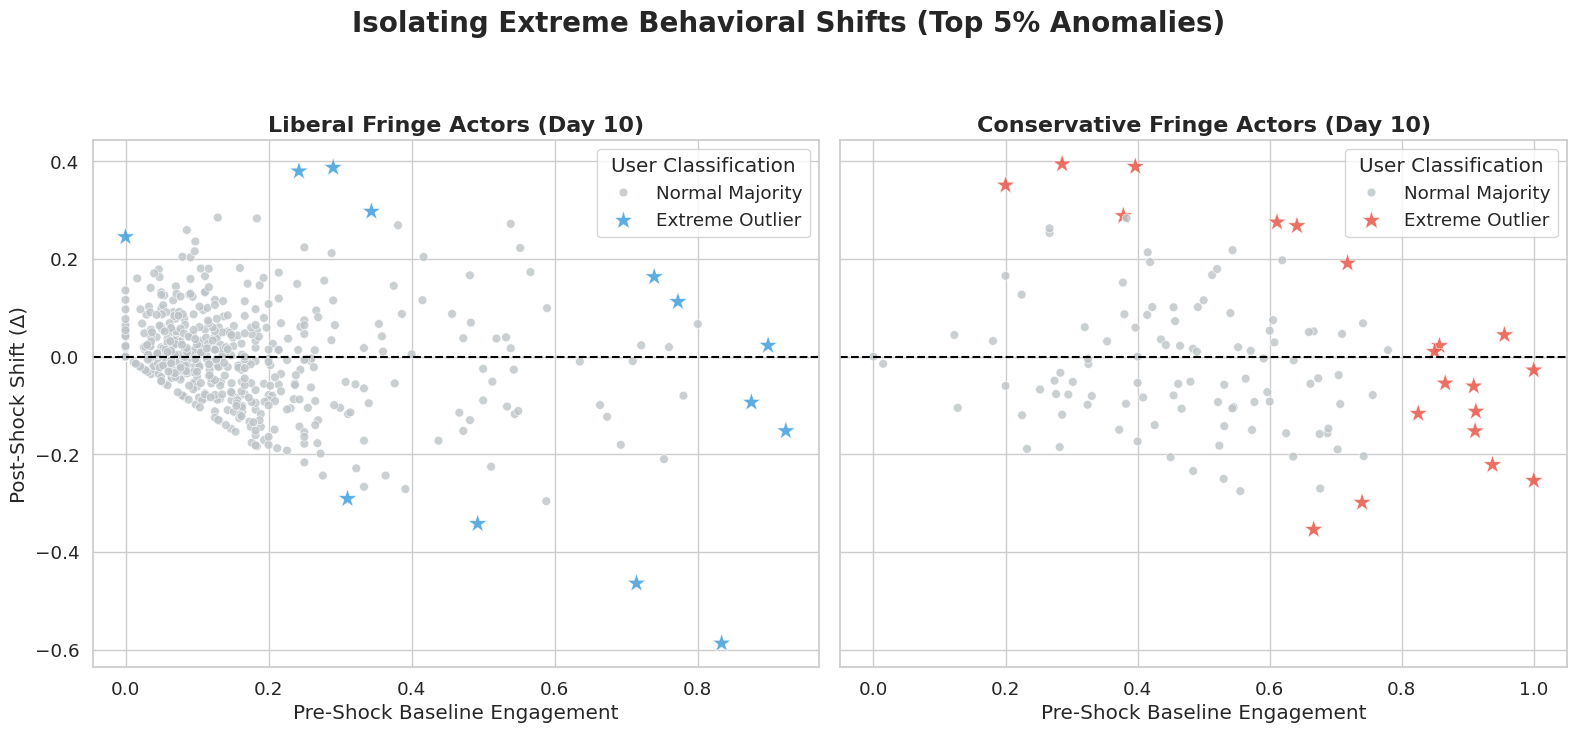

In [12]:
#!/usr/bin/env python3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# 1. Setup Directories & Load Data (Stable Day 10 Cohort)
# ==============================================================================
out_dir = "/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/outlier_analysis"
os.makedirs(out_dir, exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.2)

input_file = "/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/time_delta_oct2_locked/time_delta_oct2_lag_1days.parquet"
print(f"Loading data from: {input_file}", flush=True)

df = pd.read_parquet(input_file)
df['pol_label'] = df['pol'].map({0: 'Liberal', 1: 'Conservative'})

# Extract Empirical Features
feature_cols = ['pre_out_rate', 'delta_behavior']
clustering_data = df[feature_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(clustering_data)

# ==============================================================================
# 2. Hunt for Outliers using Isolation Forest
# ==============================================================================
print("Running Isolation Forest to detect extreme behavioral anomalies...", flush=True)

# 'contamination' is the expected percentage of outliers. 5% is standard for fringe actors.
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly_Score'] = iso_forest.fit_predict(X_scaled)

# Isolation Forest returns 1 for inliers, -1 for outliers
df['User_Type'] = df['Anomaly_Score'].map({1: 'Normal Majority', -1: 'Extreme Outlier'})

# Save the dataset so you can actually look up the UIDs of these weirdos later
data_out_path = os.path.join(out_dir, "fringe_actors_day10.parquet")
df.to_parquet(data_out_path, index=False)
print(f"--> Saved outlier dataframe to: {data_out_path}", flush=True)

# ==============================================================================
# 3. Generate the Fringe Actor Visualization
# ==============================================================================
print("Generating visualization...", flush=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Custom palette: Faint grey for normal users, bright attention colors for outliers
palette = {'Normal Majority': '#bdc3c7', 'Extreme Outlier': '#e74c3c'} # Red for outliers
palette_lib = {'Normal Majority': '#bdc3c7', 'Extreme Outlier': '#3498db'} # Blue for outliers

# ---- Plot 1: Liberal Outliers ----
sns.scatterplot(
    data=df[df['pol_label'] == 'Liberal'], 
    x='pre_out_rate', y='delta_behavior', 
    hue='User_Type', style='User_Type',
    palette=palette_lib, 
    markers={'Normal Majority': 'o', 'Extreme Outlier': '*'},
    sizes={'Normal Majority': 40, 'Extreme Outlier': 200},
    alpha=0.8, edgecolor='w', size='User_Type', ax=axes[0]
)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title("Liberal Fringe Actors (Day 10)", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Pre-Shock Baseline Engagement")
axes[0].set_ylabel("Post-Shock Shift (Δ)")
axes[0].legend(title="User Classification")

# ---- Plot 2: Conservative Outliers ----
sns.scatterplot(
    data=df[df['pol_label'] == 'Conservative'], 
    x='pre_out_rate', y='delta_behavior', 
    hue='User_Type', style='User_Type',
    palette=palette, 
    markers={'Normal Majority': 'o', 'Extreme Outlier': '*'},
    sizes={'Normal Majority': 40, 'Extreme Outlier': 200},
    alpha=0.8, edgecolor='w', size='User_Type', ax=axes[1]
)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title("Conservative Fringe Actors (Day 10)", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Pre-Shock Baseline Engagement")
axes[1].legend(title="User Classification")

plt.suptitle("Isolating Extreme Behavioral Shifts (Top 5% Anomalies)", y=1.05, fontsize=20, fontweight='bold')
plt.tight_layout()

# Save
plot_out_path = os.path.join(out_dir, "fringe_actors_scatter.png")
plt.savefig(plot_out_path, dpi=300, bbox_inches='tight')
print(f"--> Saved high-res plot to: {plot_out_path}", flush=True)
print("Pipeline complete!", flush=True)

Loading trajectories...


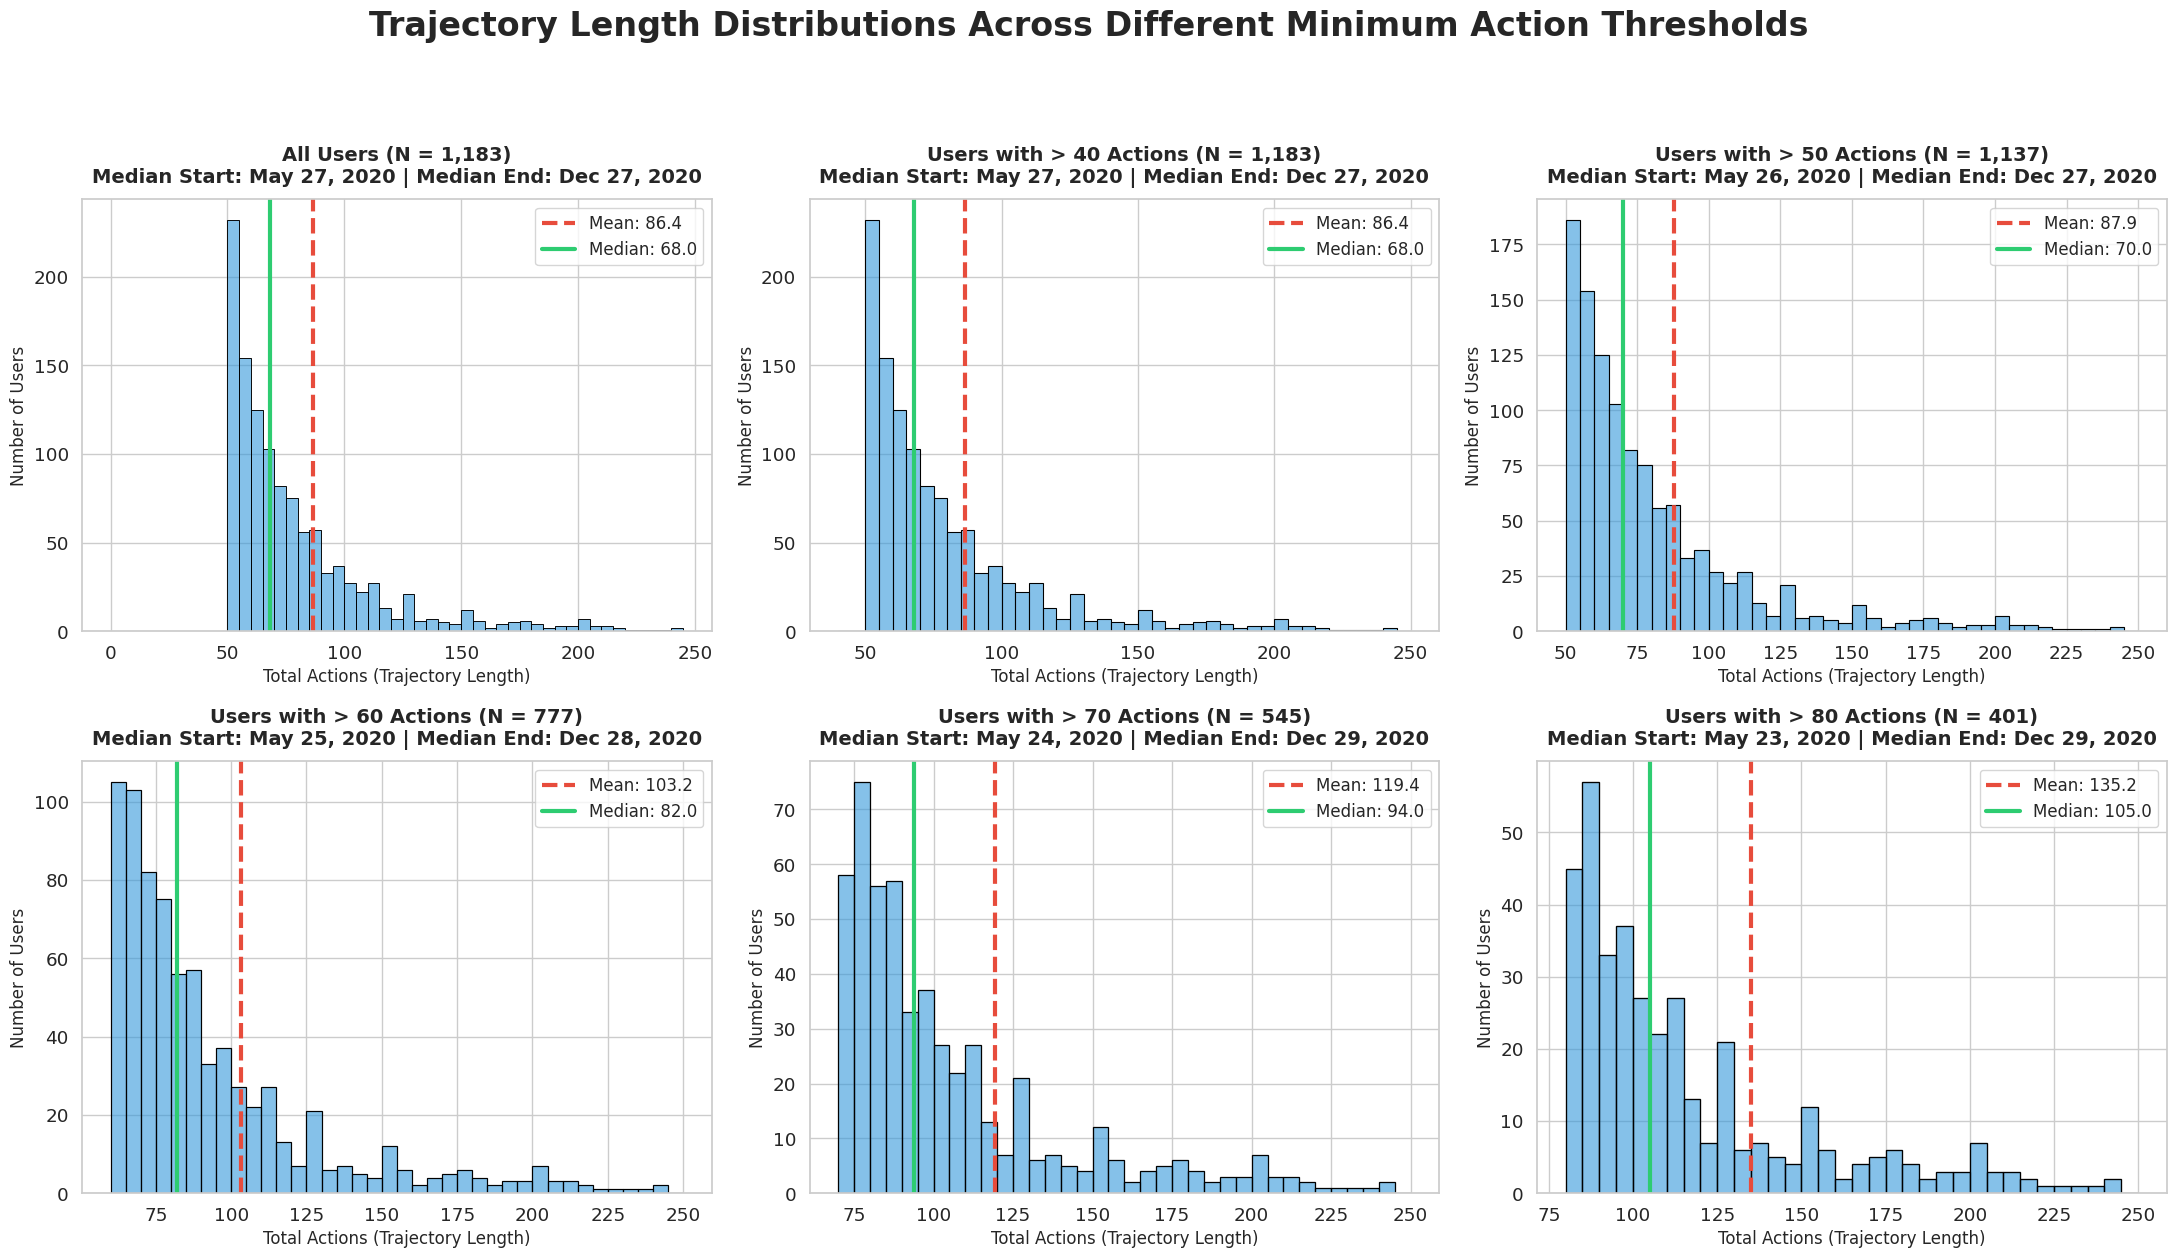

In [2]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. Setup and Data Loading
# ==============================================================================
sns.set_theme(style="whitegrid", font_scale=1.2) 

print("Loading trajectories...")
data_path = "/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/subset_50/trajectories.pkl"
with open(data_path, "rb") as f:
    trajs = pickle.load(f)

# ==============================================================================
# 2. Process Cohorts & Plot Histograms
# ==============================================================================
# We will look at the whole dataset (0), plus your requested thresholds
thresholds = [0, 40, 50, 60, 70, 80]
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for i, cutoff in enumerate(thresholds):
    # Filter users based on the cutoff bucket
    valid_trajs = [t for t in trajs if len(t["trajectory"]) > cutoff]
    
    if not valid_trajs:
        axes[i].set_visible(False)
        continue
        
    # Extract lengths and dates for this specific bucket
    lengths = [len(t["trajectory"]) for t in valid_trajs]
    start_dates = [t["trajectory"][0][0] for t in valid_trajs]
    end_dates = [t["trajectory"][-1][0] for t in valid_trajs]
    
    # Calculate exact stats (using all users in this bucket)
    mean_len = np.mean(lengths)
    median_len = np.median(lengths)
    median_start = pd.Series(pd.to_datetime(start_dates)).median().strftime('%b %d, %Y')
    median_end = pd.Series(pd.to_datetime(end_dates)).median().strftime('%b %d, %Y')
    
    ax = axes[i]
    
    # For visual clarity, we cap the X-axis of the plot at 250 
    # (Otherwise the extreme 1,300+ tweet outliers will squash the whole chart into a single pixel)
    plot_lengths = [l for l in lengths if l <= 250]
    
    # Dynamic bin sizing for clean visuals
    bins = np.arange(cutoff, min(250, max(plot_lengths)) + 10, 5)
    if cutoff == 0:
        bins = np.arange(0, 250, 5)
        
    sns.histplot(plot_lengths, bins=bins, color="#3498db", ax=ax, edgecolor='black', alpha=0.6)
    
    # Add Mean and Median vertical lines
    ax.axvline(mean_len, color='#e74c3c', linestyle='--', linewidth=3, label=f'Mean: {mean_len:.1f}')
    ax.axvline(median_len, color='#2ecc71', linestyle='-', linewidth=3, label=f'Median: {median_len:.1f}')
    
    # Formatting and Injecting Stats into the Title
    title_str = "All Users" if cutoff == 0 else f"Users with > {cutoff} Actions"
    ax.set_title(
        f"{title_str} (N = {len(lengths):,})\n"
        f"Median Start: {median_start} | Median End: {median_end}", 
        fontweight='bold', fontsize=14, pad=12
    )
    ax.set_xlabel("Total Actions (Trajectory Length)", fontsize=12)
    ax.set_ylabel("Number of Users", fontsize=12)
    
    ax.legend(loc='upper right', fontsize=12)

plt.suptitle("Trajectory Length Distributions Across Different Minimum Action Thresholds", 
             fontsize=24, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Calculating median start and end dates for each window...


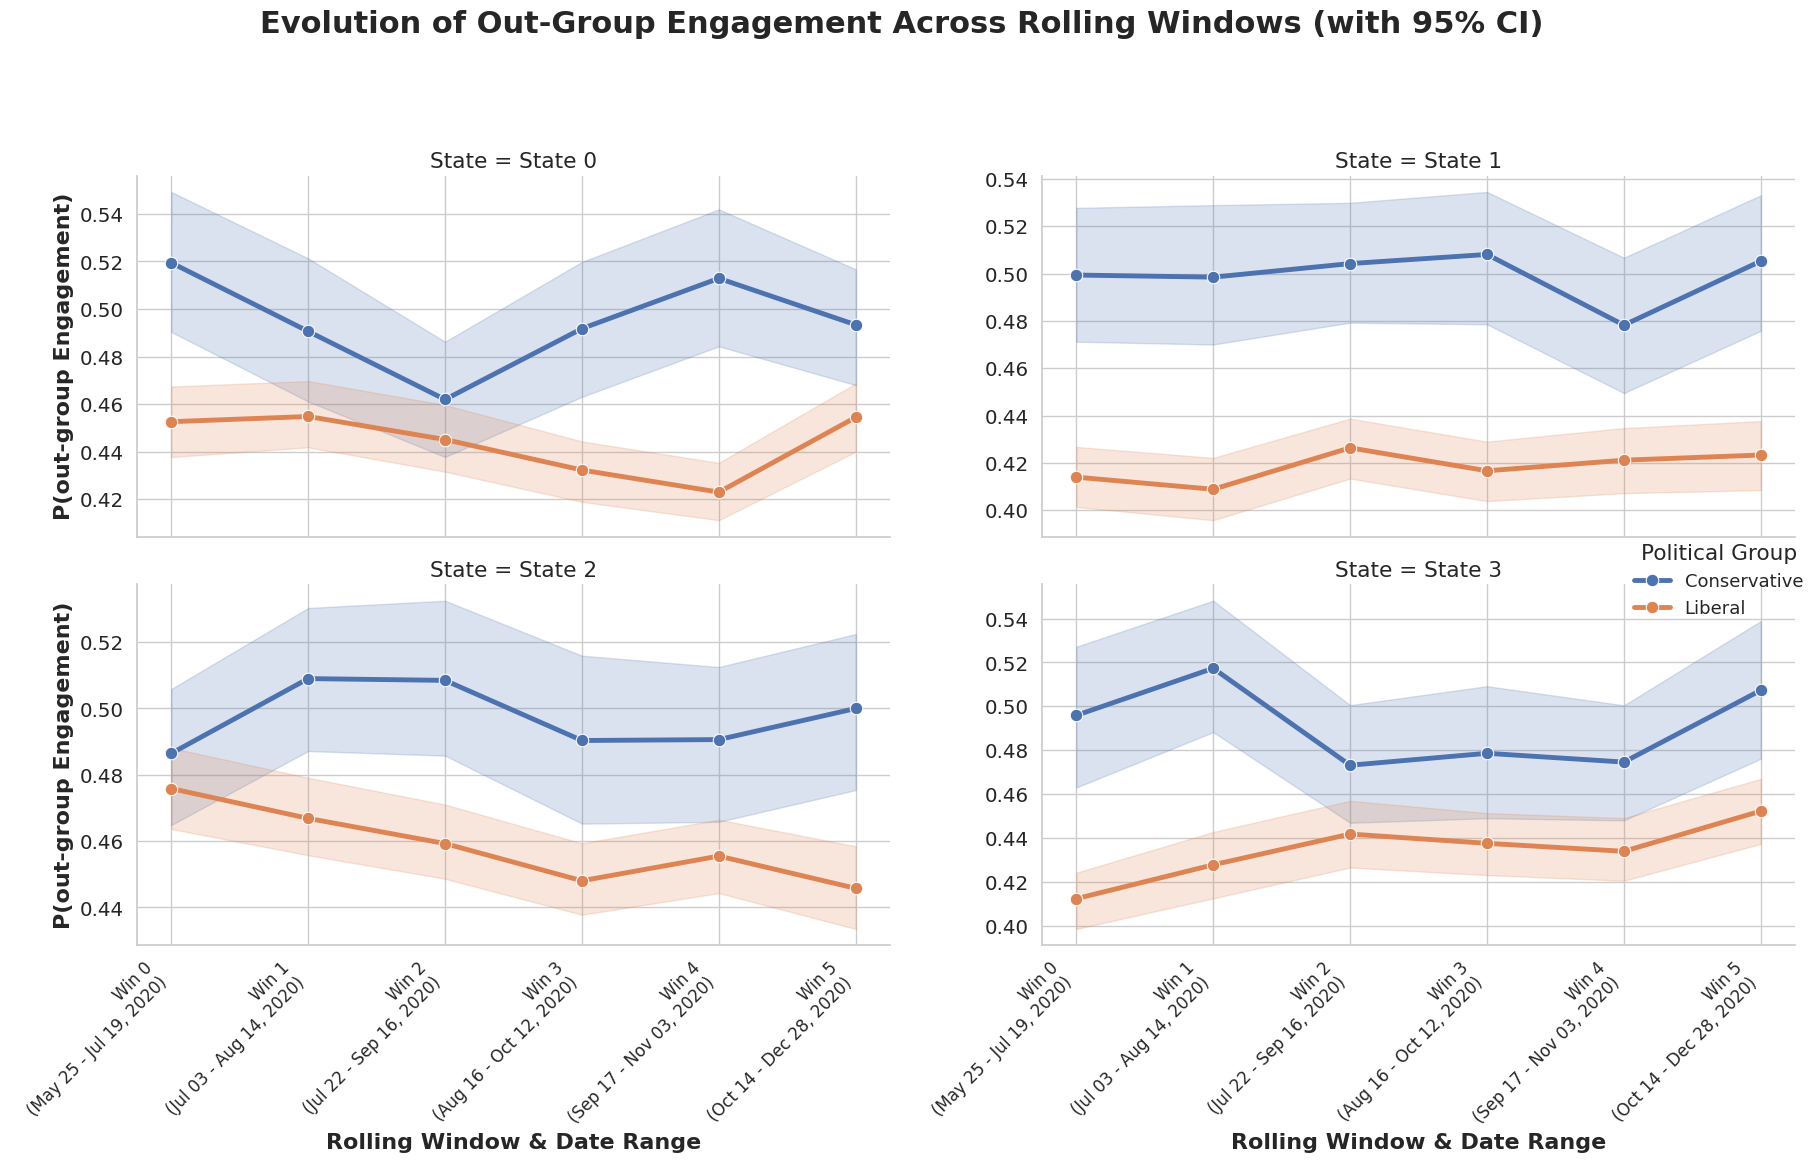

In [4]:
import os
import glob
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. Setup, Data Loading, and Font Sizing
# ==============================================================================
sns.set_theme(style="whitegrid", font_scale=1.3) 
plt.rcParams['figure.figsize'] = (16, 12)

# Load Rolling Window Results
data_dir = "/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/pre_post_shock/rolling_window_gt60"
file_pattern = os.path.join(data_dir, "rolling_irl_window_*.parquet")
file_list = glob.glob(file_pattern)

df_list = [pd.read_parquet(f) for f in file_list]
df_all = pd.concat(df_list, ignore_index=True)
df_all['pol_label'] = df_all['pol'].map({0: 'Liberal', 1: 'Conservative'})
df_all = df_all.sort_values(by='window_id')

# ==============================================================================
# 2. Map Action Windows to a Start/End Date Range
# ==============================================================================
print("Calculating median start and end dates for each window...")
traj_path = "/nas/home/dchu/IDP4CSS/Ashwin/Trajectories/subset_50/trajectories.pkl"
with open(traj_path, "rb") as f:
    trajs = pickle.load(f)

# Convert trajectories to a dictionary for instant UID lookups
traj_dict = {t["user_id"]: t["trajectory"] for t in trajs}

window_dates = {}
for w in df_all['window_id'].unique():
    w_df = df_all[df_all['window_id'] == w]
    
    start_dates = []
    end_dates = []
    
    for _, row in w_df.iterrows():
        uid = row['uid']
        s_idx = int(row['start_action'])
        e_idx = int(row['end_action'])
        
        if uid in traj_dict:
            user_traj = traj_dict[uid]
            
            # Safely grab the exact start timestamp
            if s_idx < len(user_traj):
                start_dates.append(user_traj[s_idx][0])
                
            # Safely grab the exact end timestamp (accounting for the terminal window)
            if e_idx < len(user_traj):
                end_dates.append(user_traj[e_idx][0])
            elif len(user_traj) > 0:
                end_dates.append(user_traj[-1][0])
                
    if start_dates and end_dates:
        med_start = pd.Series(pd.to_datetime(start_dates)).median()
        med_end = pd.Series(pd.to_datetime(end_dates)).median()
        
        # Format as "May 15 - Jul 22, 2020"
        start_str = med_start.strftime('%b %d')
        end_str = med_end.strftime('%b %d, %Y')
        window_dates[w] = f"{start_str} - {end_str}"
    else:
        window_dates[w] = "Unknown"

# ==============================================================================
# 3. Melt RAW Data (Instead of Aggregated) for Confidence Intervals
# ==============================================================================
n_states = 4
policy_cols = [f"policy_out_s{s}" for s in range(n_states)]

# CRITICAL CHANGE: Melt df_all directly, DO NOT groupby().mean() first.
# Seaborn needs the raw data points to calculate variance and draw the CI bands.
plot_df = pd.melt(
    df_all, 
    id_vars=['window_id', 'pol_label'], 
    value_vars=policy_cols,
    var_name='State', 
    value_name='P(out-group)'
)

plot_df['State'] = plot_df['State'].str.replace('policy_out_s', 'State ')

# ==============================================================================
# 4. Enhanced Visualization
# ==============================================================================
# Create grid with larger height
g = sns.FacetGrid(plot_df, col="State", col_wrap=2, height=5.5, aspect=1.5, sharey=False)

# Plot with thicker lines, larger markers, and automatic 95% Confidence Intervals
g.map_dataframe(
    sns.lineplot, 
    x="window_id", 
    y="P(out-group)", 
    hue="pol_label", 
    marker="o", 
    linewidth=3.5, 
    markersize=9,
    errorbar=('ci', 95)  # <--- This triggers the 95% shaded confidence band
)

# Inject our exact date range mapping into the X-axis labels
window_ids = sorted(plot_df['window_id'].unique())
x_labels = [f"Win {w}\n({window_dates[w]})" for w in window_ids]

g.set(xticks=window_ids)
g.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=12)

# Formatting Labels and Titles
g.set_axis_labels("Rolling Window & Date Range", "P(out-group Engagement)", fontsize=16, fontweight='bold')
g.add_legend(title="Political Group", title_fontsize='14', fontsize='13')

g.fig.suptitle("Evolution of Out-Group Engagement Across Rolling Windows (with 95% CI)", y=1.06, fontsize=22, fontweight='bold')

plt.tight_layout()
plt.show()